In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://drive.google.com/uc?id=1GWHKPdxVuqroKoKoB49zOEyfyLAwbzcc", encoding='latin1')

In [114]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2013-11


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

## to_datetime()
format text to datetime, give the format your date string is in: 2005-07-19 -> %Y-%m-%d


In [115]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d-%m-%Y")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

## pandas plot()
- index needs to be date time like 
- resample allows you to group the data according to frequency 
- options: ‘ME’, ‘YE’, ‘QE’, ‘BME’, ‘BA’, ‘BQE’, ‘W’ 
- you may aggregate the intervals by: sum(), mean(), median(), max(), min()

<Axes: title={'center': 'Weekly Sales'}, xlabel='Order Date'>

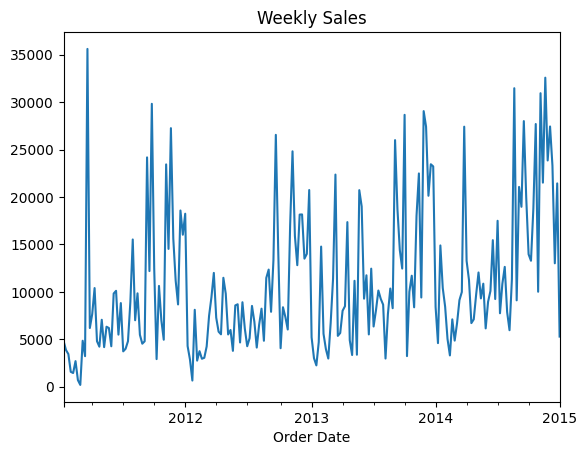

In [ ]:
(
    df.set_index("Order Date")["Sales"]
    .resample("W") # weekly
    .sum() 
    .plot
    .line(legend=False, title="Weekly Sales")
 )

## Styles

In [140]:
import matplotlib.pyplot as plt

plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

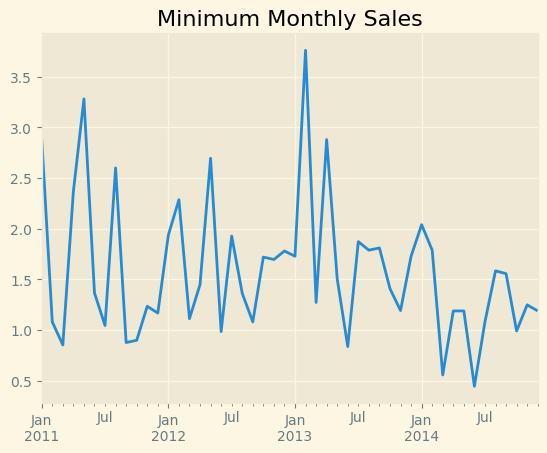

In [200]:

plt.style.use("Solarize_Light2")

(
    df.set_index("Order Date")["Sales"]
    .resample("ME") # monthly       
    .min() 
    .plot
    .line(title="Minimum Monthly Sales", xlabel="")
 )

plt.show()

In [14]:
df["Sales"].agg(["min", "max"])

min        0.444
max    22638.480
Name: Sales, dtype: float64

## plot settings ()

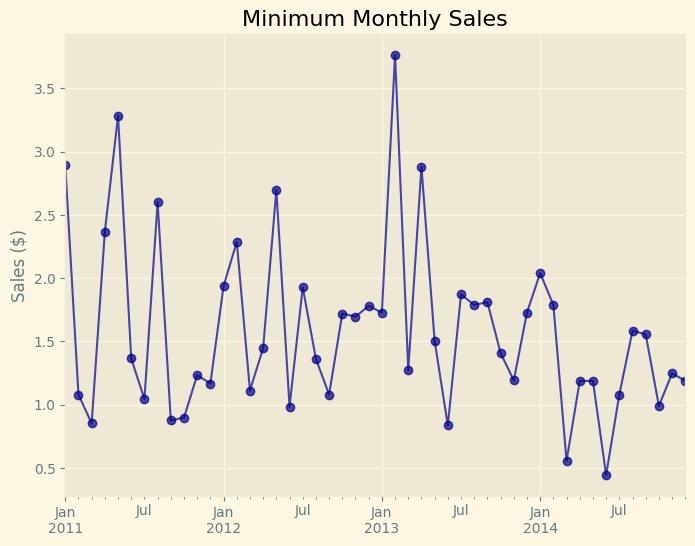

In [202]:
(
    df.set_index("Order Date")["Sales"]
    .resample("ME")  # Month-end resampling
    .min()
    .plot.line(
        title="Minimum Monthly Sales",          # Title
        xlabel="",                      # X-axis label
        ylabel="Sales ($)",             # Y-axis label
        color="darkblue",               # Line color
    linewidth=1.5,                      # Line width
        grid=True,                      # Show grid
        figsize=(8, 6),                 # Figure size
        legend=False,                   # Hide legend
        style="-o",                     # Line style (solid with circles)
        alpha=0.7,                      # Transparency
    )
)

plt.show()

## pandas plot + matplotlib

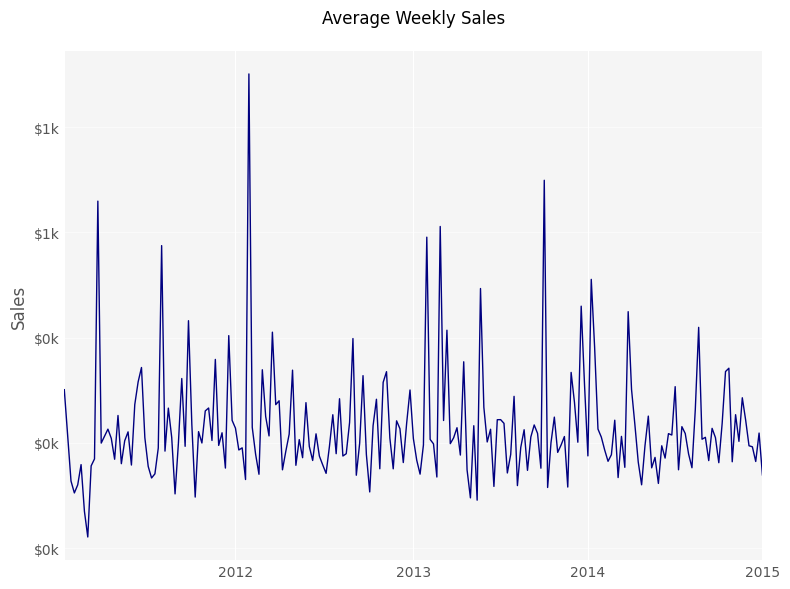

In [182]:
import matplotlib.pyplot as plt


# create an axis object to customize the plot
ax = (
    df.set_index("Order Date")["Sales"]
    .resample("W")
    .mean()
    .plot.line(
        color="navy",
        linewidth=1,
        figsize=(8, 6),
        legend=False,
    )
)

# Customize with matplotlib
plt.style.use("ggplot")

plt.title("Average Weekly Sales", fontsize=12, pad=20)
plt.xlabel("", fontsize=12)
plt.ylabel("Sales", fontsize=12)

# custom y-axis formatter to show values in thousands with a "k" suffix
def thousands(x, pos):
    """The two arguments are the value and tick position."""
    return f'${x*1e-3:1.0f}k'

# Set the custom formatter for the y-axis
ax.yaxis.set_major_formatter(thousands) 

# remove spines (borders) and customize grid
ax.spines[:].set_visible(False)

# Remove minor ticks and customize major grid
ax.tick_params(axis='both', which='both', size=0)
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.5)

# Add a background color
ax.set_facecolor("#f5f5f5") 

# Show the plot
plt.tight_layout()  # Prevent label cutoff
plt.show()